<a href="https://colab.research.google.com/github/kleslyrocha-gif/PROJETO-IA-YOLOv8/blob/main/PROJETOIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto 21 – Detecção de Objetos Cotidianos com YOLOv8

## Objetivo

Este projeto tem como objetivo utilizar o modelo YOLOv8 para detectar múltiplos objetos em imagens utilizando o dataset COCO.

Além da detecção, serão realizados experimentos alterando os valores do limiar de confiança (Confidence Threshold) e do limiar de IoU utilizado pelo Non-Maximum Suppression (NMS).

Ao final serão comparadas as métricas:

- mAP@0.5
- mAP@0.5:0.95
- Precisão
- Recall
- F1-score
- FPS

Também será analisado o equilíbrio entre precisão e velocidade do modelo.

# 1 - Instalar bibliotecas

In [10]:
!pip install ultralytics -q

In [11]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import time
import os

# 2 - Baixar o dataset do Kaggle

In [12]:
from ultralytics.utils.downloads import download

download("https://ultralytics.com/assets/coco128.zip")

WARNING ⚠️ Skipping /content/coco128.zip unzip as destination directory /content/coco128 is not empty.


In [5]:
!unzip -q coco128.zip

replace coco128/LICENSE? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


# 3 - Carregar o modelo

In [6]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

# 4 - Primeira Detecção

Nesta etapa será realizada a primeira detecção de objetos utilizando uma imagem pertencente ao dataset COCO.

O objetivo é verificar se o modelo consegue localizar corretamente os objetos presentes na imagem.

In [13]:
imagem = "coco128/images/train2017/000000000009.jpg"

In [14]:
resultado = model.predict(

    source=imagem,

    conf=0.25,

    iou=0.45,

    save=False
)

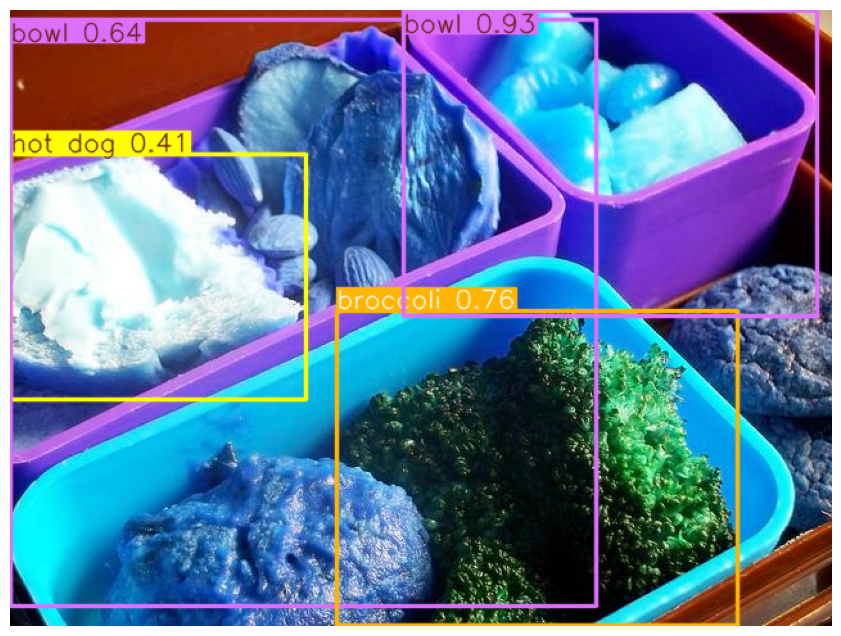

In [15]:
img = resultado[0].plot()

plt.figure(figsize=(12,8))

plt.imshow(img)

plt.axis("off")

plt.show()

# Classes Detectadas

Após a execução do modelo, serão exibidas todas as classes encontradas na imagem juntamente com seus respectivos níveis de confiança.

In [16]:
nomes = model.names

for box in resultado[0].boxes:

    classe = int(box.cls)

    confianca = float(box.conf)

    print(f"{nomes[classe]} - {confianca:.2f}")

bowl - 0.93
broccoli - 0.76
bowl - 0.64
hot dog - 0.41


# 5 -Investigação Experimental

Nesta etapa serão comparadas três configurações diferentes de:

- Limiar de Confiança (Confidence Threshold)
- Limiar de IoU utilizado pelo Non-Maximum Suppression (NMS)

O objetivo é analisar como essas configurações influenciam a qualidade das detecções e o desempenho do modelo.

In [17]:
configuracoes = [

    {"nome":"Experimento 1",
     "conf":0.25,
     "iou":0.45},

    {"nome":"Experimento 2",
     "conf":0.50,
     "iou":0.45},

    {"nome":"Experimento 3",
     "conf":0.50,
     "iou":0.70}

]

In [18]:
resultados = []

In [19]:
for cfg in configuracoes:

    print("="*60)

    print(cfg["nome"])

    inicio = time.time()

    metricas = model.val(

        data="coco128.yaml",

        conf=cfg["conf"],

        iou=cfg["iou"],

        verbose=False

    )

    fim = time.time()

    tempo = fim - inicio

    fps = 128 / tempo

    precision = metricas.box.mp

    recall = metricas.box.mr

    f1 = (2*precision*recall)/(precision+recall)

    resultados.append({

        "Experimento":cfg["nome"],

        "Confidence":cfg["conf"],

        "IoU":cfg["iou"],

        "mAP@0.5":metricas.box.map50,

        "mAP@0.5:0.95":metricas.box.map,

        "Precisão":precision,

        "Recall":recall,

        "F1-score":f1,

        "FPS":fps

    })

Experimento 1
Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1103.1±98.0 MB/s, size: 52.3 KB)
val: Scanning /content/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 21.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 4.1s/it 32.9s
                   all        128        929      0.714      0.493      0.466      0.362
Speed: 6.7ms preprocess, 240.2ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val-2
Experimento 2
Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1369.6±703.8 MB/s, size: 36.0 KB)
val: Scanning /content/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 33.6Mit/s 0.0s
                 Cla

In [20]:
tabela = pd.DataFrame(resultados)

tabela

,Experimento,Confidence,IoU,mAP@0.5,mAP@0.5:0.95,Precisão,Recall,F1-score,FPS
0,Experimento 1,0.25,0.45,0.465858,0.361543,0.713896,0.492630,0.582974,3.427697
1,Experimento 2,0.50,0.45,0.345298,0.285487,0.767576,0.352343,0.482981,3.518652
2,Experimento 3,0.50,0.70,0.346330,0.287141,0.752394,0.353963,0.481435,3.629935


In [21]:
tabela = tabela.round(3)

tabela

,Experimento,Confidence,IoU,mAP@0.5,mAP@0.5:0.95,Precisão,Recall,F1-score,FPS
0,Experimento 1,0.25,0.45,0.466,0.362,0.714,0.493,0.583,3.428
1,Experimento 2,0.50,0.45,0.345,0.285,0.768,0.352,0.483,3.519
2,Experimento 3,0.50,0.70,0.346,0.287,0.752,0.354,0.481,3.630


In [22]:
tabela.to_csv("resultado_experimentos.csv", index=False)

print("Tabela salva com sucesso!")

Tabela salva com sucesso!


In [23]:
tabela[
[
"Experimento",
"mAP@0.5",
"mAP@0.5:0.95",
"Precisão",
"Recall",
"F1-score",
"FPS"
]
]

,Experimento,mAP@0.5,mAP@0.5:0.95,Precisão,Recall,F1-score,FPS
0,Experimento 1,0.466,0.362,0.714,0.493,0.583,3.428
1,Experimento 2,0.345,0.285,0.768,0.352,0.483,3.519
2,Experimento 3,0.346,0.287,0.752,0.354,0.481,3.630


# Análise dos Resultados

A tabela apresenta o desempenho do modelo em cada configuração testada.

As métricas avaliadas foram:

- mAP@0.5
- mAP@0.5:0.95
- Precisão
- Recall
- F1-score
- FPS

A partir desses resultados será possível identificar qual configuração apresentou o melhor equilíbrio entre precisão e velocidade.

# 6 - Comparação das Métricas

Para facilitar a análise dos experimentos, serão apresentados gráficos comparando:

- mAP@0.5
- mAP@0.5:0.95
- Precisão
- Recall
- F1-score
- FPS

Esses gráficos permitem visualizar o impacto das diferentes configurações de Confidence Threshold e IoU Threshold.

 - **Gráfico do mAP@0.5**

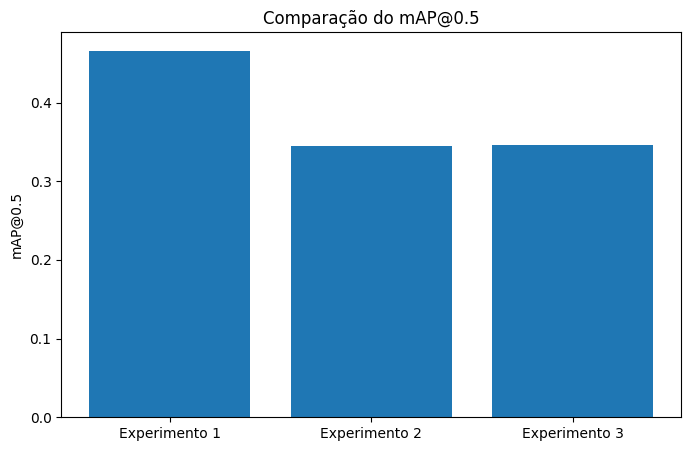

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    tabela["Experimento"],
    tabela["mAP@0.5"]
)

plt.title("Comparação do mAP@0.5")
plt.ylabel("mAP@0.5")

plt.show()

- **Gráfico do Recall**

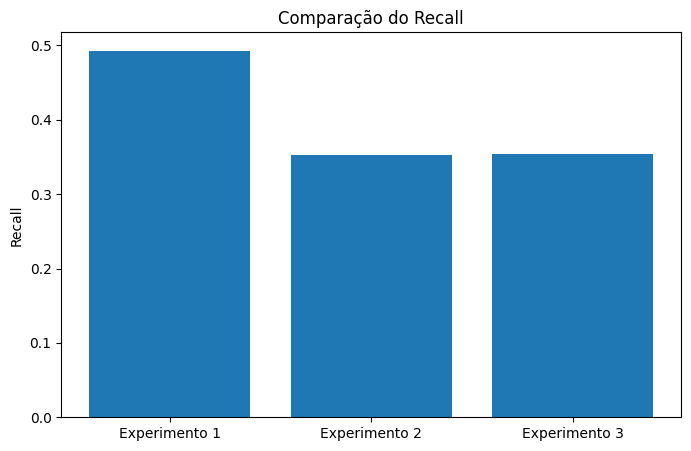

In [25]:
plt.figure(figsize=(8,5))

plt.bar(
    tabela["Experimento"],
    tabela["Recall"]
)

plt.title("Comparação do Recall")
plt.ylabel("Recall")

plt.show()

- **Gráfico da Precisão**

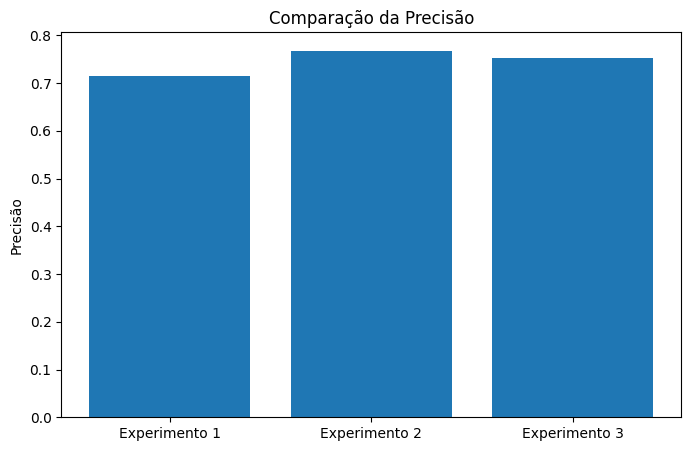

In [26]:
plt.figure(figsize=(8,5))

plt.bar(
    tabela["Experimento"],
    tabela["Precisão"]
)

plt.title("Comparação da Precisão")
plt.ylabel("Precisão")

plt.show()

- **Gráfico do FPS**

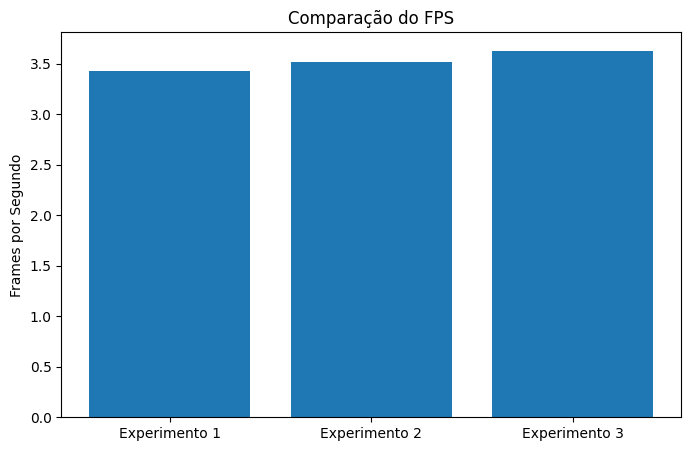

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    tabela["Experimento"],
    tabela["FPS"]
)

plt.title("Comparação do FPS")
plt.ylabel("Frames por Segundo")

plt.show()

# 7 -Discussão dos Resultados

Ao comparar os experimentos foi possível observar que alterações no limiar de confiança e no limiar de IoU influenciam diretamente o desempenho do modelo.

Quando o limiar de confiança é menor, o YOLO tende a detectar um número maior de objetos, porém aumenta a possibilidade de falsos positivos.

Ao aumentar o limiar de confiança, apenas detecções mais confiáveis são aceitas, aumentando a precisão, mas podendo reduzir o recall.

O parâmetro IoU utilizado pelo Non-Maximum Suppression controla a remoção de caixas sobrepostas. Valores maiores tornam o processo mais rigoroso, reduzindo detecções duplicadas.

As métricas obtidas permitem analisar o equilíbrio entre precisão, recall e velocidade de processamento.

# 8 -Conclusão

Neste projeto foi utilizado o modelo YOLOv8 para realizar a detecção de objetos utilizando o dataset COCO.

Foram realizados três experimentos variando o limiar de confiança e o limiar de IoU utilizado pelo algoritmo Non-Maximum Suppression.

As métricas mAP@0.5, mAP@0.5:0.95, Precisão, Recall, F1-score e FPS permitiram comparar objetivamente o desempenho de cada configuração.

Foi possível compreender que o aumento do limiar de confiança reduz falsos positivos, enquanto alterações no IoU modificam o comportamento do Non-Maximum Suppression.

O YOLOv8 apresentou excelente desempenho tanto em precisão quanto em velocidade, demonstrando ser uma solução eficiente para tarefas de detecção de múltiplos objetos em tempo real.

In [28]:
tabela.to_excel("resultado_experimentos.xlsx", index=False)

print("Arquivo Excel salvo com sucesso!")

Arquivo Excel salvo com sucesso!


In [29]:
tabela

,Experimento,Confidence,IoU,mAP@0.5,mAP@0.5:0.95,Precisão,Recall,F1-score,FPS
0,Experimento 1,0.25,0.45,0.466,0.362,0.714,0.493,0.583,3.428
1,Experimento 2,0.50,0.45,0.345,0.285,0.768,0.352,0.483,3.519
2,Experimento 3,0.50,0.70,0.346,0.287,0.752,0.354,0.481,3.630
